In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States') ].copy()

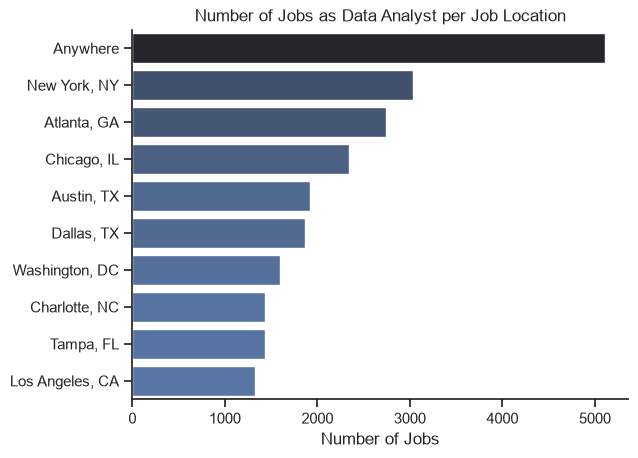

In [32]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs as Data Analyst per Job Location')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

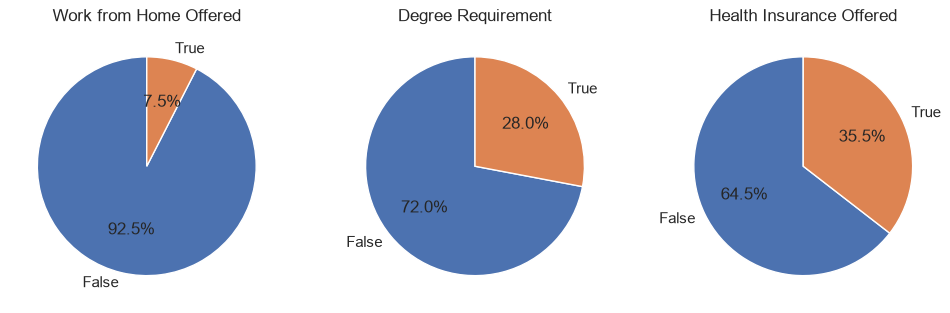

In [27]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

# plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.show()

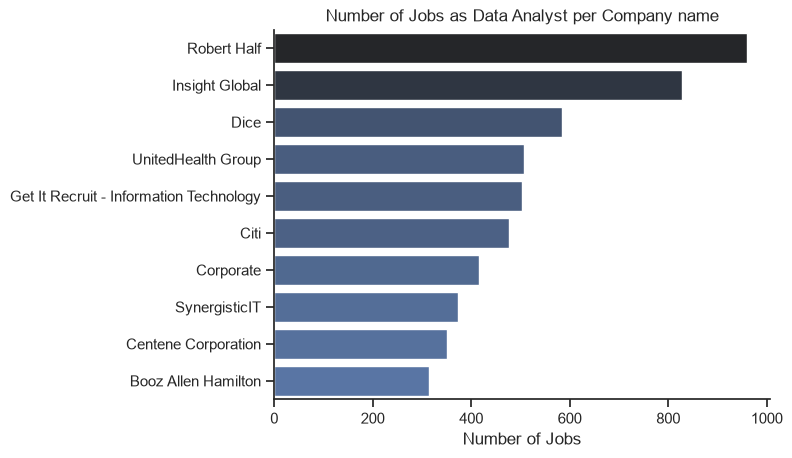

In [33]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs as Data Analyst per Company name')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

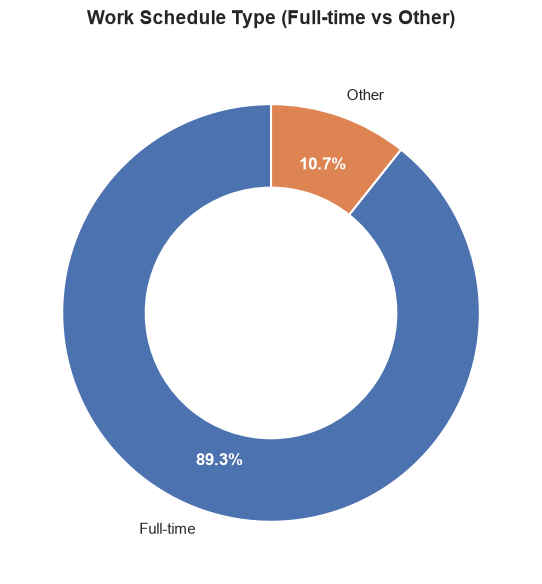

In [48]:
# 1. Map categories to 'Full-time' or 'Other'
df['schedule_group'] = df['job_schedule_type'].apply(
    lambda x: 'Full-time' if x == 'Full-time' else 'Other'
)

# 2. Get value counts
counts = df['schedule_group'].value_counts()

# 3. Plot donut chart
plt.figure(figsize=(7, 6))

wedges, texts, autotexts = plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    colors=['#4C72B0', '#DD8452'], # Blue for Full-time, Orange for Other
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=1.5)
)

# Style text inside slices
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

plt.title('Work Schedule Type (Full-time vs Other)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()